<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Forecast_SalesPRice_with_missing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_data.csv'

try:
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from URL.")
except Exception as e:
    print(f"Error loading dataset from URL: {e}")
    df = None

# Display the first 5 rows of the DataFrame
if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

Dataset loaded successfully from URL.

First 5 rows of the dataset:


,Order,MS Zoning,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
0,1,RL,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000
1,2,RH,1961.0,5.0,6,11622,730.0,0,2,1.0,5,105000
2,3,RL,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000
3,4,RL,1968.0,7.0,5,11160,522.0,0,3,2.0,8,244000
4,5,RL,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900


### Dataset Description

Let's get a general overview of the dataset, including data types, non-null values, and memory usage, followed by descriptive statistics for numerical columns.

In [2]:
if df is not None:
    print("\nDataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    display(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order          2930 non-null   int64  
 1   MS Zoning      2930 non-null   object 
 2   Year Built     2733 non-null   float64
 3   Overall Qual   2718 non-null   float64
 4   Overall Cond   2930 non-null   int64  
 5   Lot Area       2930 non-null   int64  
 6   Garage Area    2929 non-null   float64
 7   Pool Area      2930 non-null   int64  
 8   Bedroom AbvGr  2930 non-null   int64  
 9   Full Bath      2656 non-null   float64
 10  TotRms AbvGrd  2930 non-null   int64  
 11  SalePrice      2930 non-null   int64  
dtypes: float64(4), int64(7), object(1)
memory usage: 274.8+ KB

Descriptive Statistics:


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2930.00000,2733.000000,2718.000000,2930.000000,2930.000000,2929.000000,2930.000000,2930.000000,2656.000000,2930.000000,2930.000000
mean,1465.50000,1971.463227,6.158940,5.563140,10147.921843,472.819734,2.243345,2.854266,1.568148,6.443003,180796.060068
std,845.96247,30.204510,1.393679,1.111537,7880.017759,215.046549,35.597181,0.827731,0.552231,1.572964,79886.692357
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.25000,1954.000000,5.000000,5.000000,7440.250000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.50000,1974.000000,6.000000,5.000000,9436.500000,480.000000,0.000000,3.000000,2.000000,6.000000,160000.000000
75%,2197.75000,2001.000000,7.000000,6.000000,11555.250000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


### Missing Value Analysis

Now, let's analyze the missing values in the dataset. This will show us which columns have missing data and how many.

In [3]:
if df is not None:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

    print("\nMissing values in each column:")
    # Filter to show only columns with missing values and sort them
    display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

    if missing_df['Missing Count'].sum() == 0:
        print("No missing values found in the dataset.")


Missing values in each column:


,Missing Count,Missing Percentage
Full Bath,274,9.351536
Overall Qual,212,7.235495
Year Built,197,6.723549
Garage Area,1,0.034130


### Bivariate Analysis of Missing 'Full Bath' Values

Let's investigate if the missing values in the 'Full Bath' column are related to other attributes in the dataset. We'll create a new indicator column for missing 'Full Bath' and visualize its relationship with other features.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Create a boolean column indicating if 'Full Bath' is missing
    df['is_full_bath_missing'] = df['Full Bath'].isnull()
    print("Added 'is_full_bath_missing' column to the DataFrame.")
    display(df[['Full Bath', 'is_full_bath_missing']].head())
else:
    print("DataFrame 'df' is not available.")

Added 'is_full_bath_missing' column to the DataFrame.


,Full Bath,is_full_bath_missing
0,1.0,False
1,1.0,False
2,1.0,False
3,2.0,False
4,2.0,False


#### Missing 'Full Bath' by 'MS Zoning' (Categorical Feature)

We'll use a bar chart to count the number of missing 'Full Bath' values for each category within the 'MS Zoning' column.

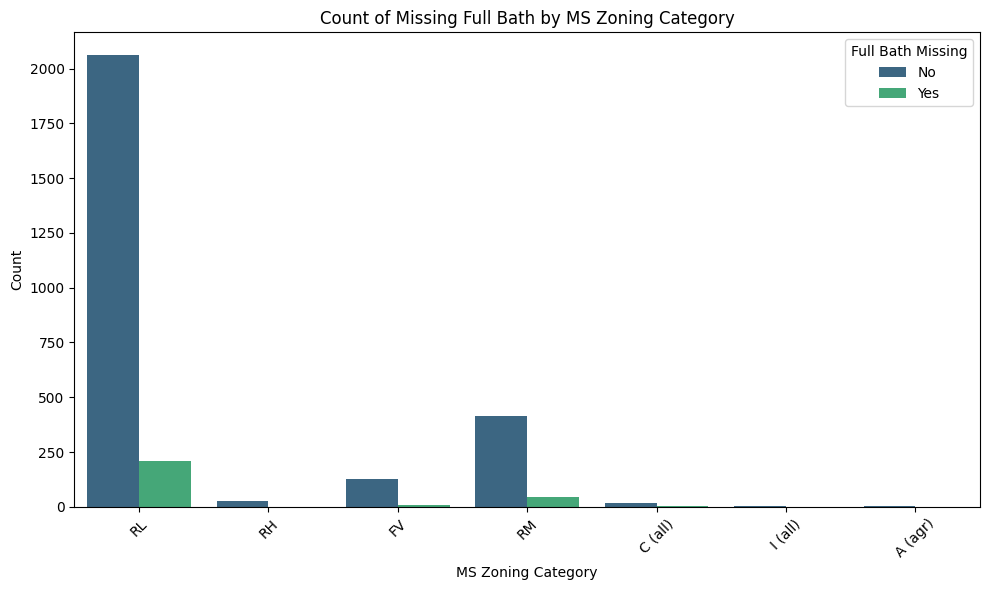

In [5]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='MS Zoning', hue='is_full_bath_missing', data=df, palette='viridis')
    plt.title('Count of Missing Full Bath by MS Zoning Category')
    plt.xlabel('MS Zoning Category')
    plt.ylabel('Count')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Lot Area' (Numerical Feature)

For numerical features like 'Lot Area', a direct bar chart of missing counts isn't ideal. Instead, we'll visualize the distribution of 'Lot Area' for rows where 'Full Bath' is missing versus where it's present, using Kernel Density Estimate (KDE) plots. This helps us see if 'Full Bath' tends to be missing for specific 'Lot Area' ranges.

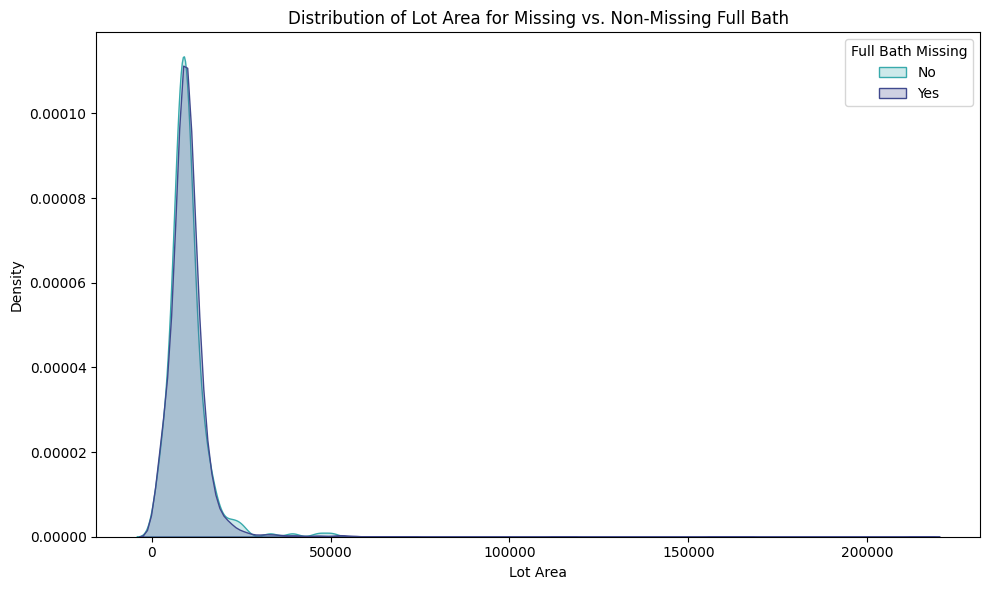

In [6]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Lot Area', hue='is_full_bath_missing', fill=True, common_norm=False, palette='mako')
    plt.title('Distribution of Lot Area for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Lot Area')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Year Built' (Numerical Feature)

Similarly, let's look at the distribution of 'Year Built' for rows with and without missing 'Full Bath' values.

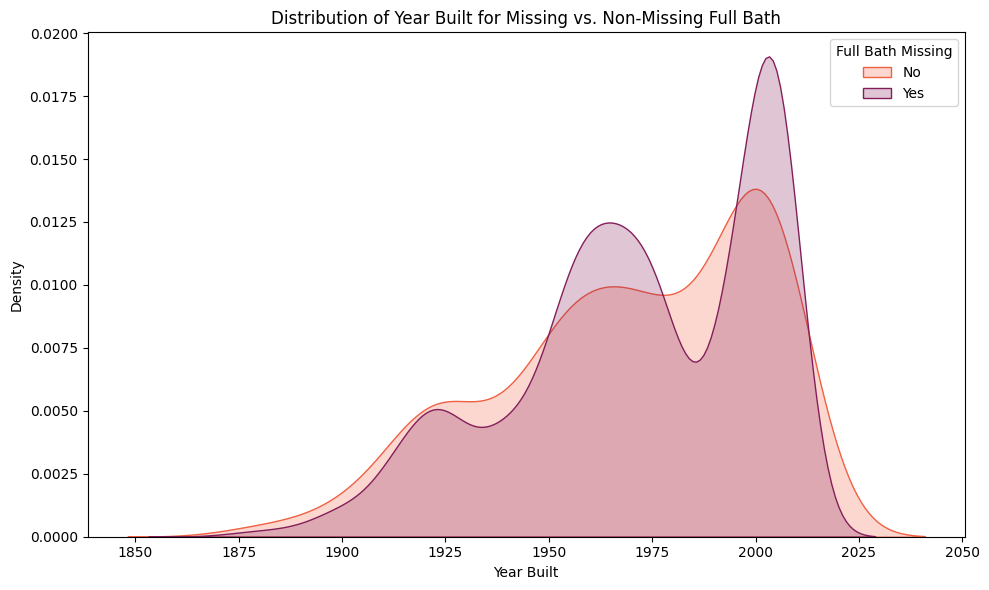

In [7]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Year Built', hue='is_full_bath_missing', fill=True, common_norm=False, palette='rocket')
    plt.title('Distribution of Year Built for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Year Built')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

In [8]:
display(df)

,Order,MS Zoning,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,is_full_bath_missing
0,1,RL,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000,False
1,2,RH,1961.0,5.0,6,11622,730.0,0,2,1.0,5,105000,False
2,3,RL,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000,False
3,4,RL,1968.0,7.0,5,11160,522.0,0,3,2.0,8,244000,False
4,5,RL,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,RL,1984.0,6.0,6,7937,588.0,0,3,1.0,6,142500,False
2926,2927,RL,1983.0,5.0,5,8885,484.0,0,2,1.0,5,131000,False
2927,2928,RL,1992.0,5.0,5,10441,0.0,0,3,1.0,6,132000,False
2928,2929,RL,1974.0,5.0,5,10010,418.0,0,2,1.0,6,170000,False


### Pearson Correlation Matrix

Let's compute the Pearson correlation matrix for the numerical attributes in the dataset to understand the relationships between them. A heatmap will be used for visualization.

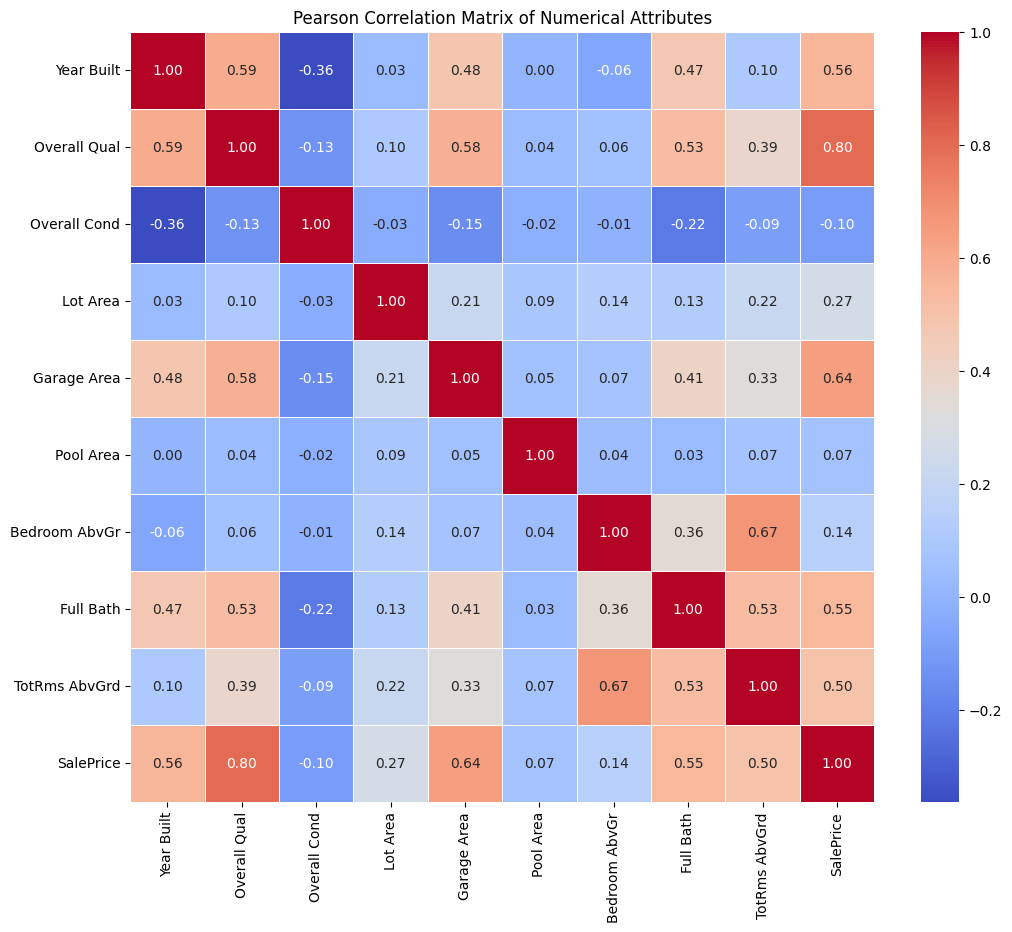

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['int64', 'float64'])

    # Drop the 'Order' column if it exists, as it's an identifier
    if 'Order' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['Order'])

    # Also drop the 'is_full_bath_missing' column if it exists, as it's an indicator variable
    if 'is_full_bath_missing' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['is_full_bath_missing'])

    # Calculate the Pearson correlation matrix
    correlation_matrix = numerical_df.corr(method='pearson')

    # Plot the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Matrix of Numerical Attributes')
    plt.show()
else:
    print("DataFrame 'df' is not available to calculate correlation matrix.")

### Data Preprocessing for Model Training

We will begin by one-hot encoding all categorical features. Then, we will address missing numerical values using a Random Forest-based imputation method. This involves iteratively training a Random Forest model to predict missing values in one column based on the non-missing values in other columns. Finally, we will drop the `Order` and `is_full_bath_missing` columns.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if df is not None:
    # Create a copy to avoid modifying the original DataFrame directly
    df_processed = df.copy()

    # Drop the 'Order' column as it's an identifier and 'is_full_bath_missing' as it's an indicator
    if 'Order' in df_processed.columns:
        df_processed = df_processed.drop(columns=['Order'])
    if 'is_full_bath_missing' in df_processed.columns:
        df_processed = df_processed.drop(columns=['is_full_bath_missing'])

    # Identify all categorical columns for one-hot encoding
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
        print(f"One-hot encoded {len(categorical_cols)} categorical columns.")
    else:
        df_encoded = df_processed
        print("No categorical columns to encode.")

    print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)
    display(df_encoded.head())

    # --- Random Forest Imputation ---
    print("\nStarting Random Forest imputation for missing numerical values...")
    df_imputed = df_encoded.copy()

    # Identify numerical columns with missing values
    cols_with_missing = df_imputed.select_dtypes(include=['int64', 'float64']).columns[df_imputed.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    # Exclude 'SalePrice' from imputation if it's in cols_with_missing (it's our target)
    if 'SalePrice' in cols_with_missing:
        cols_with_missing.remove('SalePrice')

    # Iterate and impute each column with missing values
    for col in cols_with_missing:
        print(f"  Imputing missing values in column: '{col}'")
        # Separate data into observed and missing for the current column
        df_observed = df_imputed.dropna(subset=[col])
        df_missing = df_imputed[df_imputed[col].isnull()]

        if not df_missing.empty:
            # Features to train the imputer (all other columns without missing values)
            features_for_imputation = [c for c in df_observed.columns if c != col and df_observed[c].isnull().sum() == 0]

            # If there are no features to train, fall back to mean imputation for this column
            if not features_for_imputation:
                mean_val = df_observed[col].mean()
                df_imputed.loc[df_imputed[col].isnull(), col] = mean_val
                print(f"    (Falling back to mean imputation for '{col}' due to no clean features: {mean_val:.2f})")
                continue

            X_impute_train = df_observed[features_for_imputation]
            y_impute_train = df_observed[col]
            X_impute_predict = df_missing[features_for_imputation]

            # Handle potential missing values in features_for_imputation for X_impute_predict (shouldn't happen if selected properly)
            # If there are still missing values in the imputation features, drop those rows for prediction only.
            rows_to_drop_predict = X_impute_predict.isnull().any(axis=1)
            if rows_to_drop_predict.any():
                print(f"    Warning: Dropping {rows_to_drop_predict.sum()} rows for predicting '{col}' due to missing values in imputation features.")
                X_impute_predict = X_impute_predict[~rows_to_drop_predict]
                df_missing_subset = df_missing[~rows_to_drop_predict]
            else:
                df_missing_subset = df_missing

            if not X_impute_predict.empty:
                rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
                rf_imputer.fit(X_impute_train, y_impute_train)
                predicted_values = rf_imputer.predict(X_impute_predict)
                df_imputed.loc[df_missing_subset.index, col] = predicted_values
                print(f"    Successfully imputed {len(predicted_values)} values for '{col}'.")
            else:
                print(f"    No rows left to predict for '{col}' after handling missing features.")
        else:
            print(f"    No missing values in '{col}' to impute.")

    # Verify no more missing values
    if df_imputed.isnull().sum().sum() == 0:
        print("\nAll missing values handled after Random Forest imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        display(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])

    df_cleaned = df_imputed # Final preprocessed DataFrame
    print("Shape of DataFrame after full preprocessing:", df_cleaned.shape)
    display(df_cleaned.head())
else:
    print("DataFrame 'df' is not available for preprocessing.")

### Random Forest Model Training

Now, we will train a Random Forest Regressor model to forecast 'SalePrice' using the preprocessed data. We will split the data into training and testing sets to evaluate the model's performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

if 'df_cleaned' in locals() and df_cleaned is not None:
    # Define features (X) and target (y)
    X = df_cleaned.drop('SalePrice', axis=1)
    y = df_cleaned['SalePrice']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data split into training and testing sets.")
    print(f"Training features shape: {X_train.shape}")
    print(f"Testing features shape: {X_test.shape}")
else:
    print("Cleaned DataFrame 'df_cleaned' is not available for model training.")

In [ ]:
if 'X_train' in locals() and 'y_train' in locals():
    # Initialize and train the Random Forest Regressor model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor model trained successfully.")
else:
    print("Training data is not available to train the model.")

### Model Evaluation

Let's evaluate the performance of the trained Random Forest model on the test set using R-squared and Mean Squared Error.

In [ ]:
if 'rf_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"R-squared: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.2f}")

    # Display feature importances (optional but good for understanding the model)
    feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    print("\nTop 10 Feature Importances:")
    display(feature_importances.nlargest(10))
else:
    print("Model or test data is not available for evaluation.")

### Data Preprocessing for Model Training

Following the updated instructions, we will first impute missing numerical values with the mean of their respective columns. Then, we will one-hot encode the 'MS Zoning' categorical feature. We will also drop the `Order` column as it is an identifier and the `is_full_bath_missing` column as it was created for analysis and not for model features.

In [12]:
import pandas as pd

if df is not None:
    # Create a copy to avoid modifying the original DataFrame directly for imputation
    df_processed = df.copy()

    # Drop the 'Order' column as it's an identifier and 'is_full_bath_missing' as it's an indicator
    if 'Order' in df_processed.columns:
        df_processed = df_processed.drop(columns=['Order'])
    if 'is_full_bath_missing' in df_processed.columns:
        df_processed = df_processed.drop(columns=['is_full_bath_missing'])

    # Impute missing numerical values with the mean of their column
    numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if df_processed[col].isnull().any():
            mean_value = df_processed[col].mean()
            df_processed[col] = df_processed[col].fillna(mean_value)
            print(f"Imputed missing values in '{col}' with its mean: {mean_value:.2f}")

    # One-hot encode 'MS Zoning' column
    if 'MS Zoning' in df_processed.columns:
        df_encoded = pd.get_dummies(df_processed, columns=['MS Zoning'], drop_first=True)
        print("One-hot encoded 'MS Zoning' column.")
    else:
        df_encoded = df_processed # If MS Zoning is not present or already handled

    # Verify no more missing values
    if df_encoded.isnull().sum().sum() == 0:
        print("All missing values handled.")
    else:
        print("Warning: Some missing values still exist after processing.")
        display(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

    df_cleaned = df_encoded # Rename for consistency with previous steps
    print("Shape of DataFrame after preprocessing:", df_cleaned.shape)
    display(df_cleaned.head())
else:
    print("DataFrame 'df' is not available for preprocessing.")

Imputed missing values in 'Year Built' with its mean: 1971.46
Imputed missing values in 'Overall Qual' with its mean: 6.16
Imputed missing values in 'Garage Area' with its mean: 472.82
Imputed missing values in 'Full Bath' with its mean: 1.57
One-hot encoded 'MS Zoning' column.
All missing values handled.
Shape of DataFrame after preprocessing: (2930, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,1.0,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,2.0,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False,False,False,False,True,False


In [16]:
    print("\nDescriptive Statistics:")
    display(df.describe())


Descriptive Statistics:


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2930.00000,2733.000000,2718.000000,2930.000000,2930.000000,2929.000000,2930.000000,2930.000000,2656.000000,2930.000000,2930.000000
mean,1465.50000,1971.463227,6.158940,5.563140,10147.921843,472.819734,2.243345,2.854266,1.568148,6.443003,180796.060068
std,845.96247,30.204510,1.393679,1.111537,7880.017759,215.046549,35.597181,0.827731,0.552231,1.572964,79886.692357
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.25000,1954.000000,5.000000,5.000000,7440.250000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.50000,1974.000000,6.000000,5.000000,9436.500000,480.000000,0.000000,3.000000,2.000000,6.000000,160000.000000
75%,2197.75000,2001.000000,7.000000,6.000000,11555.250000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


### Random Forest Model Training

Now, we will train a Random Forest Regressor model to forecast 'SalePrice' using the preprocessed data. We will split the data into training and testing sets to evaluate the model's performance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

if 'df_cleaned' in locals() and df_cleaned is not None:
    # Define features (X) and target (y)
    X = df_cleaned.drop('SalePrice', axis=1)
    y = df_cleaned['SalePrice']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data split into training and testing sets.")
    print(f"Training features shape: {X_train.shape}")
    print(f"Testing features shape: {X_test.shape}")
else:
    print("Cleaned DataFrame 'df_cleaned' is not available for model training.")

Data split into training and testing sets.
Training features shape: (2344, 15)
Testing features shape: (586, 15)


In [14]:
if 'X_train' in locals() and 'y_train' in locals():
    # Initialize and train the Random Forest Regressor model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor model trained successfully.")
else:
    print("Training data is not available to train the model.")

Random Forest Regressor model trained successfully.


### Model Evaluation

Let's evaluate the performance of the trained Random Forest model on the test set using R-squared and Mean Squared Error.

In [17]:
if 'rf_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"R-squared: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.2f}")

    # Display feature importances (optional but good for understanding the model)
    feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    print("\nTop 10 Feature Importances:")
    display(feature_importances.nlargest(10))
else:
    print("Model or test data is not available for evaluation.")

R-squared: 0.8350
Mean Squared Error: 1323275492.28

Top 10 Feature Importances:


,0
Overall Qual,0.607483
Garage Area,0.106941
Lot Area,0.100269
Year Built,0.052201
Full Bath,0.047096
TotRms AbvGrd,0.034830
Overall Cond,0.017208
Bedroom AbvGr,0.016515
Pool Area,0.005813
MS Zoning_RL,0.005730
